In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [4]:
load_dotenv()
subgraph_llm=ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [6]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [7]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [8]:
parent_llm=ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [10]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

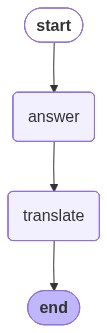

In [13]:
graph = parent_builder.compile()

graph

In [14]:

graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': "**Quantum Physics: A Brief Introduction**\n\nQuantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. It's a fundamental theory that explains how the physical world works at the quantum level.\n\n**Key Principles:**\n\n1. **Wave-Particle Duality**: Quantum objects, like electrons, can exhibit both wave-like and particle-like behavior.\n2. **Uncertainty Principle**: It's impossible to know certain properties of a quantum object, like position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, like spinning both clockwise and counterclockwise at the same time.\n4. **Entanglement**: Quantum objects can become connected in a way that their properties are correlated, even when separated by large distances.\n\n**Applications:**